In [20]:
import os
from collections import defaultdict
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import sympy

from experiments.feynman_dm import FeynmanDataModule, TransformedFeynmanDataModule
from experiments.utils import evaluate_expression

In [13]:
run_dirs = {r.stem.split("_")[-1]: r for r in Path("lasr_runs/exp_50").glob("*/run_logs_*.csv")}
# run_dirs = {r.stem.split("_")[-1]: r for r in Path("lasr_runs/exp_0.bk").glob("*/run_logs_*.csv")}
transformed_run_dirs = {os.path.basename(r.parent): r for r in Path("lasr_runs/exp_51").glob("*/run_logs_*.csv")}

In [16]:
grouped_run_dirs = defaultdict(list)

for k,v in run_dirs.items():
    grouped_run_dirs[k].append(v)

for k,v in transformed_run_dirs.items():
    grouped_run_dirs[k.split('_')[0]].append(v)

In [17]:
grouped_run_dirs

defaultdict(list,
            {'I.6.2b': [PosixPath('lasr_runs/exp_50/I.6.2b/run_logs_I.6.2b.csv')],
             'I.6.2a': [PosixPath('lasr_runs/exp_50/I.6.2a/run_logs_I.6.2a.csv'),
              PosixPath('lasr_runs/exp_51/I.6.2a_0_0/run_logs_I.6.2a_0_0.csv')],
             'I.6.2': [PosixPath('lasr_runs/exp_50/I.6.2/run_logs_I.6.2.csv')]})

In [18]:
# for run_result_csv in run_dirs:
#     df = pd.read_csv(run_result_csv, header = None)
#     df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
#     break

eq_name = "I.6.2a"

runs = grouped_run_dirs[eq_name]

dfs = []
for run in runs:
    df = pd.read_csv(run, header = None)
    df.columns = ['Iteration', 'Complexity', 'Loss', 'Score', 'Expression', 'Time']
    selected_id = df.groupby(by="Iteration")['Loss'].idxmin()
    grouped_df = df.loc[selected_id].copy()
    grouped_df['sympy_format'] = grouped_df['Expression'].apply(lambda s: sympy.sympify(s))
    dfs.append(grouped_df)
    # expression = sympy.sympify()

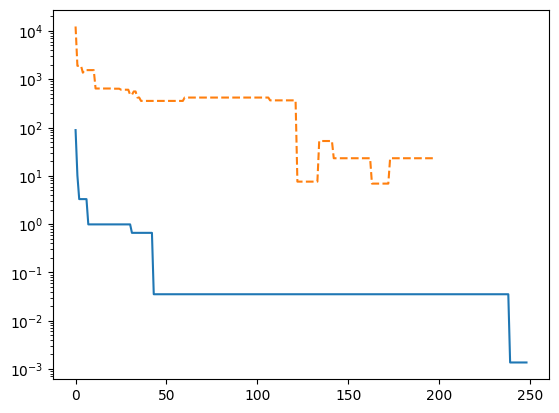

In [19]:
plt.plot(dfs[0]['Loss'].values, linestyle='-')
for i, s in enumerate(dfs[1:]):
    plt.plot(s['Loss'].values, linestyle='--')
plt.yscale("log")